In [1]:
# Install dependencies

!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.5 MB/s eta 0:00:00


In [2]:
# Mount google drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Paths of directories

drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc"
code_data_path = f"{root_path}/code-data"

dataset_path = f"{code_data_path}/dataset"
current_path = f"{code_data_path}/training/2d_material"
saved_models_path = f"{code_data_path}/training/saved_models"

In [4]:
import sys

sys.path.append(f"{drive_path}/master/shared_code")
from my_torch import MLP, to_tensor, find_best_threshold

In [5]:
# Load original dataset

import pandas as pd

dataset = pd.read_pickle(f"{dataset_path}/dataset_2d_solvent_features_hsp_pubchem_bp.pkl")
dataset['molecular_weight'] = pd.to_numeric(dataset['molecular_weight'], errors='coerce')  # convert to numeric
dataset = dataset.fillna(dataset.mean(numeric_only=True))  # fill nan with mean

print(dataset.shape)
dataset.head()

(235, 35)


,c2db_id,normalized_value,gap,work_function,formation_energy,ehull,alphax_el,alphay_el,alphaz_el,plasmafrequency_x,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg
0,1BN-1,0.210000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,1,1,0,4,0,0,0,1,455.7,760.00
1,1BN-1,0.477404,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,1,1,1,4,0,0,0,1,370.3,760.00
2,1BN-1,0.546929,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,0,1,0,4,0,0,0,1,329.3,760.00
3,1BN-1,0.360000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,0,1,0,8,0,0,0,1,380.2,17.25
4,1BN-1,0.389386,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,...,0,1,0,6,0,0,0,1,438.2,760.00


In [6]:
# Dataset for machine learning

df = dataset.select_dtypes(include=['number'])  # remove non-numeric columns

print(df.shape)
df.head()

(235, 33)


,normalized_value,gap,work_function,formation_energy,ehull,alphax_el,alphay_el,alphaz_el,plasmafrequency_x,plasmafrequency_y,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg
0,0.210000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,1,1,0,4,0,0,0,1,455.7,760.00
1,0.477404,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,1,1,1,4,0,0,0,1,370.3,760.00
2,0.546929,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,0,1,0,4,0,0,0,1,329.3,760.00
3,0.360000,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,0,1,0,8,0,0,0,1,380.2,17.25
4,0.389386,5.675449,5.664127,-1.292174,0.0,0.960341,0.960341,0.152404,0.0,0.0,...,0,1,0,6,0,0,0,1,438.2,760.00


In [7]:
mat_features = ['gap', 'work_function', 'formation_energy', 'ehull',
       'alphax_el', 'alphay_el', 'alphaz_el', 'plasmafrequency_x',
       'plasmafrequency_y', 'dyn_stab', 'has_inversion_symmetry', 'dE_zx',
       'dE_zy']

df_base = df[mat_features]
df0 = df.drop(columns=mat_features)

df1 = df_base.rename(columns={col: f"{col}_1" for col in df_base.columns})
df2 = df_base.rename(columns={col: f"{col}_2" for col in df_base.columns})
df3 = df_base.rename(columns={col: f"{col}_3" for col in df_base.columns})

extended_df  = pd.concat([df0, df1, df2, df3], axis=1)
extended_df.head()

,normalized_value,delta_d,delta_p,delta_h,molar_volume,molecular_weight,xlogp,charge,tpsa,complexity,...,ehull_3,alphax_el_3,alphay_el_3,alphaz_el_3,plasmafrequency_x_3,plasmafrequency_y_3,dyn_stab_3,has_inversion_symmetry_3,dE_zx_3,dE_zy_3
0,0.210000,17.4,18.8,15.9,59.1,59.07,-1.0,0,29.1,20.0,...,0.0,0.960341,0.960341,0.152404,0.0,0.0,0,0,0.0,0.0
1,0.477404,16.0,6.8,17.4,75.2,60.10,0.3,0,20.2,7.2,...,0.0,0.960341,0.960341,0.152404,0.0,0.0,0,0,0.0,0.0
2,0.546929,15.5,10.4,7.0,74.0,58.08,-0.1,0,17.1,26.3,...,0.0,0.960341,0.960341,0.152404,0.0,0.0,0,0,0.0,0.0
3,0.360000,18.0,10.5,9.7,108.1,114.15,-0.5,0,23.6,101.0,...,0.0,0.960341,0.960341,0.152404,0.0,0.0,0,0,0.0,0.0
4,0.389386,16.8,11.5,10.2,92.5,87.12,-0.8,0,20.3,58.6,...,0.0,0.960341,0.960341,0.152404,0.0,0.0,0,0,0.0,0.0


In [8]:
import os, json, random
import joblib
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

thresholds = np.linspace(0.1, 0.9, 81)  # 81 evenly spaced probability values from 0.1 to 0.9

best_params_path = f"{saved_models_path}/mlp_2d_material_solvent_params.json"
best_model_path = f"{saved_models_path}/mlp_2d_material_solvent_model.pth"
training_loss_path = f"{saved_models_path}/mlp_2d_material_solvent_training_loss.json"
scaler_path = f"{saved_models_path}/mlp_2d_material_solvent_scaler.pkl"

In [9]:
# X, y datasets

target_value_threshold = extended_df["normalized_value"].mean()

X = extended_df.drop(columns=["normalized_value"])
# y = (extended_df["normalized_value"] >= target_value_threshold).astype(int)
y = extended_df["normalized_value"]

# Initial y value threshold for y binarization
y_values = y.values if hasattr(y, "values") else y

y_binary_thresh = np.median(y_values)
print(f"Threshold for y binarization: {y_binary_thresh:.3f}")
y_binary = (y_values >= y_binary_thresh).astype(int)

# Split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=SEED, stratify=y_binary
)

# Normalize
scaler = StandardScaler()

X_trainval_scaled = scaler.fit_transform(X_trainval)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, scaler_path)

# To tensor
X_trainval_t, y_trainval_t = to_tensor(X_trainval_scaled, y_trainval)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test)

Threshold for y binarization: 0.296


In [10]:
# Hyperparameter tuning and final training

# Optuna objective with k-fold cv
def objective(trial, X_data, y_data):
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128, 256])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_scores = []

    for train_idx, val_idx in kf.split(X_data, y_data):
        X_train, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_train, y_val = y_data[train_idx], y_data[val_idx]

        local_scaler = StandardScaler()
        X_train = local_scaler.fit_transform(X_train)
        X_val = local_scaler.transform(X_val)

        X_train_t, y_train_t = to_tensor(X_train, y_train)
        X_val_t, y_val_t = to_tensor(X_val, y_val)

        model = MLP(input_dim=X.shape[1], hidden_dim=hidden_dim, dropout=dropout)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Train
        model.train()
        for epoch in range(30):
            permutation = torch.randperm(X_train_t.size(0), generator=torch.Generator().manual_seed(SEED))
            for i in range(0, X_train_t.size(0), batch_size):
                idx = permutation[i:i+batch_size]
                batch_x, batch_y = X_train_t[idx], y_train_t[idx]

                optimizer.zero_grad()
                outputs = model(batch_x).squeeze()
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        # Validation: get probabilities
        model.eval()
        with torch.no_grad():
            outputs = model(X_val_t).squeeze()
            probs = torch.sigmoid(outputs).cpu().numpy()
            y_true_val = y_val_t.cpu().numpy()
            _, best_f1_fold, _ = find_best_threshold(y_true_val, probs, thresholds)

        fold_scores.append(best_f1_fold)

    return np.mean(fold_scores)



# Hyperparameter tuning
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(lambda trial: objective(trial, X_trainval, y_trainval), n_trials=50)
best_params = study.best_params

# Save hyperparameters to json
pretrained_params = {
    'input_dim': X.shape[1],
    'hidden_dim': best_params['hidden_dim'],
    'dropout': best_params['dropout'],
    'output_dim': 1,  # binary classification
    'batch_size': best_params['batch_size'],
    'lr': best_params['lr'],
    'best_f1': study.best_value  # best f1 score
}

with open(best_params_path, "w") as f:
    json.dump(pretrained_params, f)
print("Pretrained hyperparameters saved as mlp_2d_material_solvent_params.json")

print("Best hyperparameters:", best_params)

# Final training on full train+val
model = MLP(input_dim=X.shape[1],
            hidden_dim=best_params['hidden_dim'],
            dropout=best_params['dropout'])

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
batch_size = best_params['batch_size']

epochs = 100
loss_list = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_trainval_t.size(0), generator=torch.Generator().manual_seed(SEED))
    for i in range(0, X_trainval_t.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        batch_x, batch_y = X_trainval_t[idx], y_trainval_t[idx]

        optimizer.zero_grad()
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    loss_list.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Save pretrained model weights
torch.save(model.state_dict(), best_model_path)
print("Pretrained model saved as mlp_2d_material_solvent_model.pth")

# Save training loss list
with open(training_loss_path, "w") as f:
    json.dump(loss_list, f)
print("Training loss saved to mlp_2d_material_solvent_training_loss.json")


Pretrained hyperparameters saved as mlp_2d_material_solvent_params.json
Best hyperparameters: {'hidden_dim': 128, 'dropout': 0.2552755890702077, 'lr': 0.005467383930047565, 'batch_size': 32}
Epoch [10/100], Loss: 0.4508
Epoch [20/100], Loss: 0.2296
Epoch [30/100], Loss: 0.2591
Epoch [40/100], Loss: 0.0891
Epoch [50/100], Loss: 0.1414
Epoch [60/100], Loss: 0.0454
Epoch [70/100], Loss: 0.1661
Epoch [80/100], Loss: 0.0374
Epoch [90/100], Loss: 0.0112
Epoch [100/100], Loss: 0.0317
Pretrained model saved as mlp_2d_material_solvent_model.pth
Training loss saved to mlp_2d_material_solvent_training_loss.json


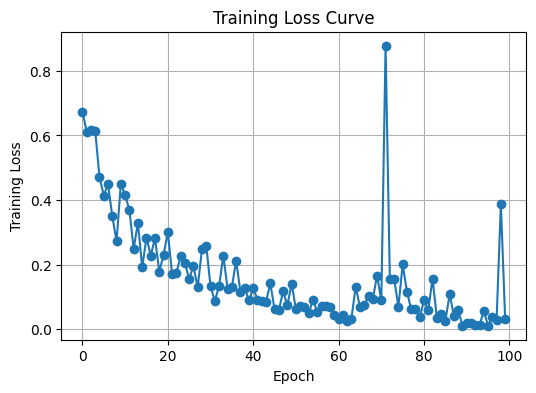

In [11]:
# Training loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [12]:
# Evaluate on hold-out test set
model.eval()
with torch.no_grad():
    outputs = model(X_test_t).squeeze()
    probs_test = torch.sigmoid(outputs).cpu().numpy()
    y_true_test = y_test_t.cpu().numpy()

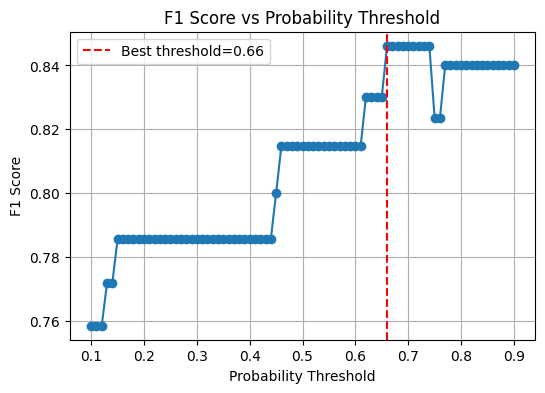


Best threshold for model outputs: 0.66
F1 score on test set: 0.8462


In [13]:
# Best test f1 score and threshold
best_thresh_test, best_f1_test, f1_scores = find_best_threshold(y_true_test, probs_test, thresholds)

y_pred_test = (probs_test >= best_thresh_test).astype(int)

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_thresh_test, color='r', linestyle='--', label=f"Best threshold={best_thresh_test:.2f}")
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Probability Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest threshold for model outputs: {best_thresh_test:.2f}")
print(f"F1 score on test set: {best_f1_test:.4f}")

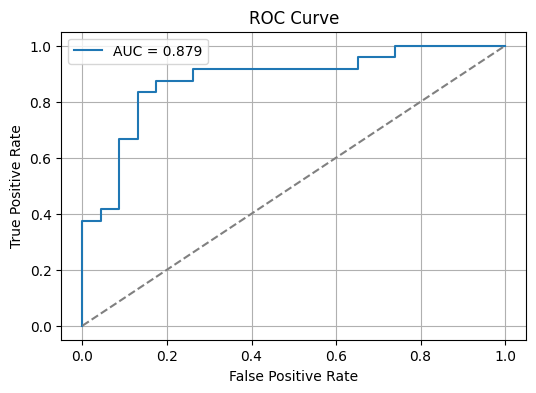

In [14]:
# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true_test, probs_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

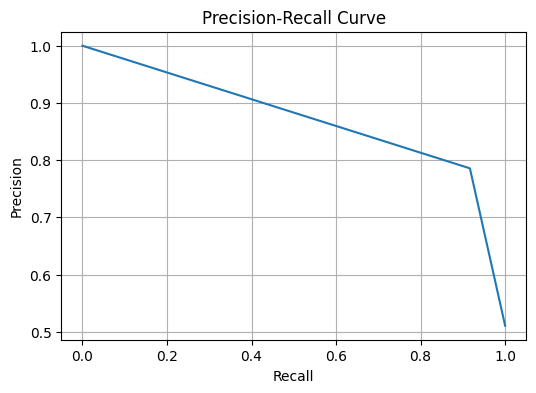

In [15]:
# Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_true_test, y_pred_test)
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [16]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.74      0.81        23
         1.0       0.79      0.92      0.85        24

    accuracy                           0.83        47
   macro avg       0.84      0.83      0.83        47
weighted avg       0.84      0.83      0.83        47



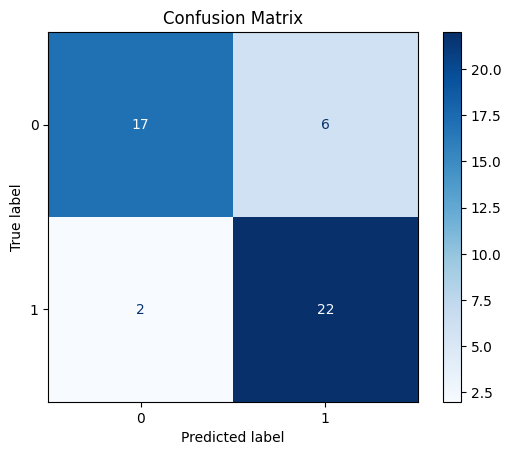

In [17]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
